In [19]:
#Task 1 : Data Loading

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



In [2]:
# Load Dataset
# Change the file path according to your system
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Credit Card Clients Dataset\UCI_Credit_Card.csv")



In [3]:
# Display First 5 Rows
print("First 5 Records")
print(df.head())

First 5 Records
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       

In [4]:
# Display Last 5 Rows
print("\nLast 5 Records")
print(df.tail())


Last 5 Records
          ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
29995  29996   220000.0    1          3         1   39      0      0      0   
29996  29997   150000.0    1          3         2   43     -1     -1     -1   
29997  29998    30000.0    1          2         2   37      4      3      2   
29998  29999    80000.0    1          3         1   41      1     -1      0   
29999  30000    50000.0    1          2         1   46      0      0      0   

       PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
29995      0  ...    88004.0    31237.0    15980.0    8500.0   20000.0   
29996     -1  ...     8979.0     5190.0        0.0    1837.0    3526.0   
29997     -1  ...    20878.0    20582.0    19357.0       0.0       0.0   
29998      0  ...    52774.0    11855.0    48944.0   85900.0    3409.0   
29999      0  ...    36535.0    32428.0    15313.0    2078.0    1800.0   

       PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.n

In [5]:
# Dataset Shape
print("\nDataset Shape")
print(df.shape)

# Column Names
print("\nColumn Names")
print(df.columns)

# Dataset Information
print("\nDataset Information")
print(df.info())

# Statistical Summary
print("\nStatistical Summary")
print(df.describe())

# Check Data Types
print("\nData Types")
print(df.dtypes)

# Check Duplicate Records
print("\nDuplicate Records :", df.duplicated().sum())

# Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())


Dataset Shape
(30000, 25)

Column Names
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0             

In [6]:

# Display Dataset Shape

print("Dataset Shape Before Cleaning :", df.shape)



Dataset Shape Before Cleaning : (30000, 25)


In [7]:
# Check Missing Values

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [8]:
# Remove Duplicate Records
duplicates = df.duplicated().sum()
print("\nDuplicate Records :", duplicates)


Duplicate Records : 0


In [9]:
# Drop duplicate rows (if any)
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates :", df.shape)


Dataset Shape After Removing Duplicates : (30000, 25)


In [10]:

# Check Data Types

print("\nData Types")
print(df.dtypes)

# Check Unique Values in Each Column

print("\nUnique Values in Each Column")

for col in df.columns:
    print(f"{col} : {df[col].nunique()}")


Data Types
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object

Unique Values in Each C

In [11]:

# Check Target Variable Distribution

print("\nTarget Variable Distribution")
print(df["default.payment.next.month"].value_counts())
print("\nTarget Variable Percentage")
print(df["default.payment.next.month"].value_counts(normalize=True)*100)

# Check Numeric Columns

numeric_columns = df.select_dtypes(include=np.number).columns
print("\nNumeric Columns")
print(numeric_columns)

# Check Categorical Columns

categorical_columns = df.select_dtypes(exclude=np.number).columns
print("\nCategorical Columns")
print(categorical_columns)


# Check for Negative Values

print("\nNegative Values Count")
for col in numeric_columns:
    count = (df[col] < 0).sum()
    if count > 0:
        print(col, ":", count)

# Save Clean Dataset

df.to_csv("credit_card_default_clean.csv", index=False)
print("\nClean Dataset Saved Successfully")



Target Variable Distribution
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target Variable Percentage
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

Numeric Columns
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

Categorical Columns
Index([], dtype='object')

Negative Values Count
PAY_0 : 8445
PAY_2 : 9832
PAY_3 : 10023
PAY_4 : 10035
PAY_5 : 10085
PAY_6 : 10635
BILL_AMT1 : 590
BILL_AMT2 : 669
BILL_AMT3 : 655
BILL_AMT4 : 675
BILL_AMT5 : 655
BILL_AMT6 : 688

Clean Dataset Saved Successfully


In [12]:
# Task 3 : Exploratory Data Analysis (EDA)

# Display Dataset Shape

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

# Display First 5 Records

print("\n" + "="*60)
print("FIRST 5 RECORDS")
print("="*60)
print(df.head())

# Display Last 5 Records

print("\n" + "="*60)
print("LAST 5 RECORDS")
print("="*60)
print(df.tail())


# Display Column Names

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())


# Dataset Information

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())


# Check Data Types

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)


# Statistical Summary

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

# Check Missing Values

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# Total Missing Values

print("\nTotal Missing Values :", df.isnull().sum().sum())


# Check Duplicate Records

print("\n" + "="*60)
print("DUPLICATE RECORDS")
print("="*60)
print("Duplicate Rows :", df.duplicated().sum())

# Check Unique Values

print("\n" + "="*60)
print("UNIQUE VALUES")
print("="*60)

for column in df.columns:
    print(f"{column} : {df[column].nunique()}")

# Target Variable Distribution

print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)

print(df["default.payment.next.month"].value_counts())

# Target Variable Percentage

print("\nTarget Variable Percentage")

print(
    round(
        df["default.payment.next.month"].value_counts(normalize=True) * 100,
        2
    )
)


# Separate Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("\n" + "="*60)
print("NUMERICAL COLUMNS")
print("="*60)

print(numerical_columns.tolist())

print("\nTotal Numerical Columns :", len(numerical_columns))

print("\n" + "="*60)
print("CATEGORICAL COLUMNS")
print("="*60)

print(categorical_columns.tolist())

print("\nTotal Categorical Columns :", len(categorical_columns))

# Correlation Matrix

print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)

correlation = df.corr(numeric_only=True)

print(correlation)

# Correlation with Target Variable
# ----------------------------------------------------------
print("\n" + "="*60)
print("CORRELATION WITH TARGET")
print("="*60)

target_corr = correlation["default.payment.next.month"].sort_values(ascending=False)

print(target_corr)

# ----------------------------------------------------------
# Skewness
# ----------------------------------------------------------
print("\n" + "="*60)
print("SKEWNESS")
print("="*60)

print(df.skew(numeric_only=True))

# ----------------------------------------------------------
# Outlier Detection Using IQR
# ----------------------------------------------------------
print("\n" + "="*60)
print("OUTLIER COUNT")
print("="*60)

Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (
        (df[numerical_columns] < (Q1 - 1.5 * IQR)) |
        (df[numerical_columns] > (Q3 + 1.5 * IQR))
    )
).sum()

print(outliers)

# ----------------------------------------------------------
# Memory Usage
# ----------------------------------------------------------
print("\n" + "="*60)
print("MEMORY USAGE")
print("="*60)

print(df.memory_usage(deep=True))

# ----------------------------------------------------------
# EDA Completed
# ----------------------------------------------------------
print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)


DATASET SHAPE
(30000, 25)

FIRST 5 RECORDS
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.pa

In [14]:
 #Task 4 : Feature Engineering
# Display Dataset Shape

print("Dataset Shape :", df.shape)
df.rename(columns={
    "default.payment.next.month": "Default"
}, inplace=True)

# Check Dataset
print(df.head())


# Separate Features and Target
X = df.drop("Default", axis=1)

y = df["Default"]

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

# Check Target Distribution
print("\nTarget Distribution")
print(y.value_counts())


# Check Categorical Columns
categorical_columns = X.select_dtypes(include="object").columns

print("\nCategorical Columns")
print(categorical_columns)


# One-Hot Encoding (Only if categorical columns exist)
if len(categorical_columns) > 0:

    X = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True
    )

print("\nShape After Encoding :", X.shape)


# Check Missing Values Again
print("\nMissing Values")
print(X.isnull().sum().sum())


# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert Back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nScaled Dataset")
print(X_scaled.head())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display Shapes
# ----------------------------------------------------------
print("\nTraining Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)


# Save Processed Dataset
processed_df = X_scaled.copy()
processed_df["Default"] = y.values

processed_df.to_csv(
    "credit_card_default_feature_engineered.csv",
    index=False
)

print("\nFeature Engineering Completed Successfully")

Dataset Shape : (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  Default  
0       0.0    

In [16]:
# Credit Card Default Prediction
# Task 6 : Weight of Evidence (WoE)

# Display Dataset Shape

print("Dataset Shape :", df.shape)


# Separate Target Variable
target = "Default"

# Select Numerical Columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove Target Column
numerical_columns.remove(target)


# Create Empty Dictionary

woe_dict = {}

# Copy Dataset
woe_df = df.copy()


# Calculate WoE

for col in numerical_columns:

    # Create 10 Equal Frequency Bins
    woe_df[col+"_BIN"] = pd.qcut(
        woe_df[col],
        q=10,
        duplicates="drop"
    )

    # Create WoE Table
    temp = pd.crosstab(
        woe_df[col+"_BIN"],
        woe_df[target]
    )

    # Rename Columns
    temp.columns = ["Good","Bad"]

    # Avoid Division by Zero
    temp["Good"] = temp["Good"] + 0.5
    temp["Bad"] = temp["Bad"] + 0.5

    # Distribution
    temp["Good_Dist"] = temp["Good"] / temp["Good"].sum()
    temp["Bad_Dist"] = temp["Bad"] / temp["Bad"].sum()

    # WoE Formula
    temp["WoE"] = np.log(
        temp["Good_Dist"] /
        temp["Bad_Dist"]
    )

    # Save WoE Table
    woe_dict[col] = temp

    # Display WoE Table
    print("\n")
    print("="*60)
    print("Feature :", col)
    print("="*60)
    print(temp)


# WoE Calculation Completed
print("\nWoE Calculation Completed Successfully.")

Dataset Shape : (30000, 25)


Feature : ID
                      Good    Bad  Good_Dist  Bad_Dist       WoE
ID_BIN                                                          
(0.999, 3000.9]     2332.5  668.5   0.099812  0.100663 -0.008488
(3000.9, 6000.8]    2355.5  645.5   0.100796  0.097199  0.036335
(6000.8, 9000.7]    2293.5  707.5   0.098143  0.106535 -0.082051
(9000.7, 12000.6]   2327.5  673.5   0.099598  0.101415 -0.018086
(12000.6, 15000.5]  2316.5  684.5   0.099127  0.103072 -0.039024
(15000.5, 18000.4]  2227.5  773.5   0.095319  0.116473 -0.200438
(18000.4, 21000.3]  2354.5  646.5   0.100753  0.097350  0.034363
(21000.3, 24000.2]  2426.5  574.5   0.103834  0.086508  0.182557
(24000.2, 27000.1]  2397.5  603.5   0.102593  0.090875  0.121288
(27000.1, 30000.0]  2337.5  663.5   0.100026  0.099910  0.001161


Feature : LIMIT_BAL
                         Good     Bad  Good_Dist  Bad_Dist       WoE
LIMIT_BAL_BIN                                                       
(9999.999, 30000.

In [17]:
# Credit Card Default Prediction
# Task 7 : Information Value (IV)


# Target Variable

target = "Default"

# Select Numerical Columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove Target Variable
numerical_columns.remove(target)


# Empty List to Store IV Values

iv_values = []


# Calculate IV for Each Feature

for col in numerical_columns:

    # Create Equal Frequency Bins
    temp = df[[col, target]].copy()

    temp["Bins"] = pd.qcut(
        temp[col],
        q=10,
        duplicates="drop"
    )

    # Crosstab
    iv_table = pd.crosstab(
        temp["Bins"],
        temp[target]
    )

    # Rename Columns
    iv_table.columns = ["Good", "Bad"]

    # Add 0.5 to Avoid Division by Zero
    iv_table["Good"] = iv_table["Good"] + 0.5
    iv_table["Bad"] = iv_table["Bad"] + 0.5

    # Distribution
    iv_table["Good_Dist"] = iv_table["Good"] / iv_table["Good"].sum()

    iv_table["Bad_Dist"] = iv_table["Bad"] / iv_table["Bad"].sum()

    # Weight of Evidence
    iv_table["WOE"] = np.log(
        iv_table["Good_Dist"] /
        iv_table["Bad_Dist"]
    )

    # Information Value
    iv_table["IV"] = (
        iv_table["Good_Dist"] -
        iv_table["Bad_Dist"]
    ) * iv_table["WOE"]

    # Total IV
    total_iv = iv_table["IV"].sum()

    # Save Result
    iv_values.append([col, total_iv])


# Create IV DataFrame

iv_df = pd.DataFrame(
    iv_values,
    columns=["Feature", "IV"]
)


# Sort IV Values

iv_df = iv_df.sort_values(
    by="IV",
    ascending=False
)


# Display IV Values

print("="*60)
print("INFORMATION VALUE")
print("="*60)

print(iv_df)


# IV Interpretation

def interpret_iv(iv):
    if iv < 0.02:
        return "Not Useful"
    elif iv < 0.10:
        return "Weak Predictor"
    elif iv < 0.30:
        return "Medium Predictor"
    elif iv < 0.50:
        return "Strong Predictor"
    else:
        return "Suspiciously Powerful"

iv_df["Interpretation"] = iv_df["IV"].apply(interpret_iv)

print("\n")
print("="*60)
print("IV WITH INTERPRETATION")
print("="*60)

print(iv_df)


# Save IV Result

iv_df.to_csv(
    "information_value.csv",
    index=False
)

print("\nInformation Value Saved Successfully.")

INFORMATION VALUE
      Feature        IV
6       PAY_0  0.869501
7       PAY_2  0.542281
8       PAY_3  0.410817
9       PAY_4  0.359186
10      PAY_5  0.329290
11      PAY_6  0.288394
1   LIMIT_BAL  0.177886
18   PAY_AMT1  0.160858
19   PAY_AMT2  0.147281
20   PAY_AMT3  0.122454
23   PAY_AMT6  0.090140
21   PAY_AMT4  0.089719
22   PAY_AMT5  0.080892
3   EDUCATION  0.036034
5         AGE  0.020603
17  BILL_AMT6  0.019198
16  BILL_AMT5  0.014032
12  BILL_AMT1  0.011977
13  BILL_AMT2  0.011129
15  BILL_AMT4  0.010958
14  BILL_AMT3  0.010324
0          ID  0.009955
4    MARRIAGE  0.005669
2         SEX  0.000000


IV WITH INTERPRETATION
      Feature        IV         Interpretation
6       PAY_0  0.869501  Suspiciously Powerful
7       PAY_2  0.542281  Suspiciously Powerful
8       PAY_3  0.410817       Strong Predictor
9       PAY_4  0.359186       Strong Predictor
10      PAY_5  0.329290       Strong Predictor
11      PAY_6  0.288394       Medium Predictor
1   LIMIT_BAL  0.177886     

In [20]:
# Credit Card Default Prediction
# Task 8 : Logistic Regression

# Import Required Libraries-
# Load Dataset
# Separate Features and Target
X = df.drop("Default", axis=1)
y = df["Default"]
# Train Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)


# Create Logistic Regression Model

model = LogisticRegression(
    max_iter=1000,
    random_state=42

)


# Train Model

model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)


# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print("LOGISTIC REGRESSION ACCURACY")
print("="*60)

print("Accuracy :", round(accuracy*100,2),"%")


# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)

print("\n")
print("="*60)
print("CONFUSION MATRIX")
print("="*60)

print(cm)


# Classification Report

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(y_test,y_pred))


# Coefficients

coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]

})

coef = coef.sort_values(
    by="Coefficient",
    ascending=False

)

print("\n")
print("="*60)
print("FEATURE COEFFICIENTS")
print("="*60)

print(coef)


# Intercept

print("\nIntercept :",model.intercept_[0])


# Prediction Example
prediction = model.predict(X_test.iloc[[0]])

print("\nPrediction for First Test Record :",prediction[0])


# Actual Value

print("Actual Value :",y_test.iloc[0])
print("\nLogistic Regression Completed Successfully")

LOGISTIC REGRESSION ACCURACY
Accuracy : 80.78 %


CONFUSION MATRIX
[[4501  172]
 [ 981  346]]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.67      0.26      0.38      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.61      0.63      6000
weighted avg       0.79      0.81      0.77      6000



FEATURE COEFFICIENTS
      Feature   Coefficient
6       PAY_0  4.398866e-01
7       PAY_2  2.008006e-01
8       PAY_3  1.247844e-01
9       PAY_4  8.984079e-02
10      PAY_5  5.349973e-02
11      PAY_6  5.082252e-02
0          ID  3.217893e-06
13  BILL_AMT2  1.376710e-06
14  BILL_AMT3  7.700787e-07
16  BILL_AMT5  4.953779e-07
1   LIMIT_BAL -9.004715e-08
20   PAY_AMT3 -4.571852e-07
17  BILL_AMT6 -6.309644e-07
15  BILL_AMT4 -8.334693e-07
22   PAY_AMT5 -1.219741e-06
23   PAY_AMT6 -2.201849e-06
21   PAY_AMT4 -2.568891e-06
12  BILL_AMT1 -3.734090e-06


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DECISION TREE ACCURACY
Accuracy : 81.78 %

Confusion Matrix
[[4433  240]
 [ 853  474]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000


Feature Importance
      Feature  Importance
6       PAY_0    0.679744
7       PAY_2    0.137618
20   PAY_AMT3    0.042839
10      PAY_5    0.033105
12  BILL_AMT1    0.031692
1   LIMIT_BAL    0.021906
8       PAY_3    0.011472
5         AGE    0.007987
0          ID    0.007453
9       PAY_4    0.006574
3   EDUCATION    0.005234
23   PAY_AMT6    0.003814
22   PAY_AMT5    0.002972
19   PAY_AMT2    0.002728
16  BILL_AMT5    0.001136
2         SEX    0.001097
15  BILL_AMT4    0.000974
4    MARRIAGE    0.000853
17  BILL_AMT6    0.000802
11      PAY_6    0.0000

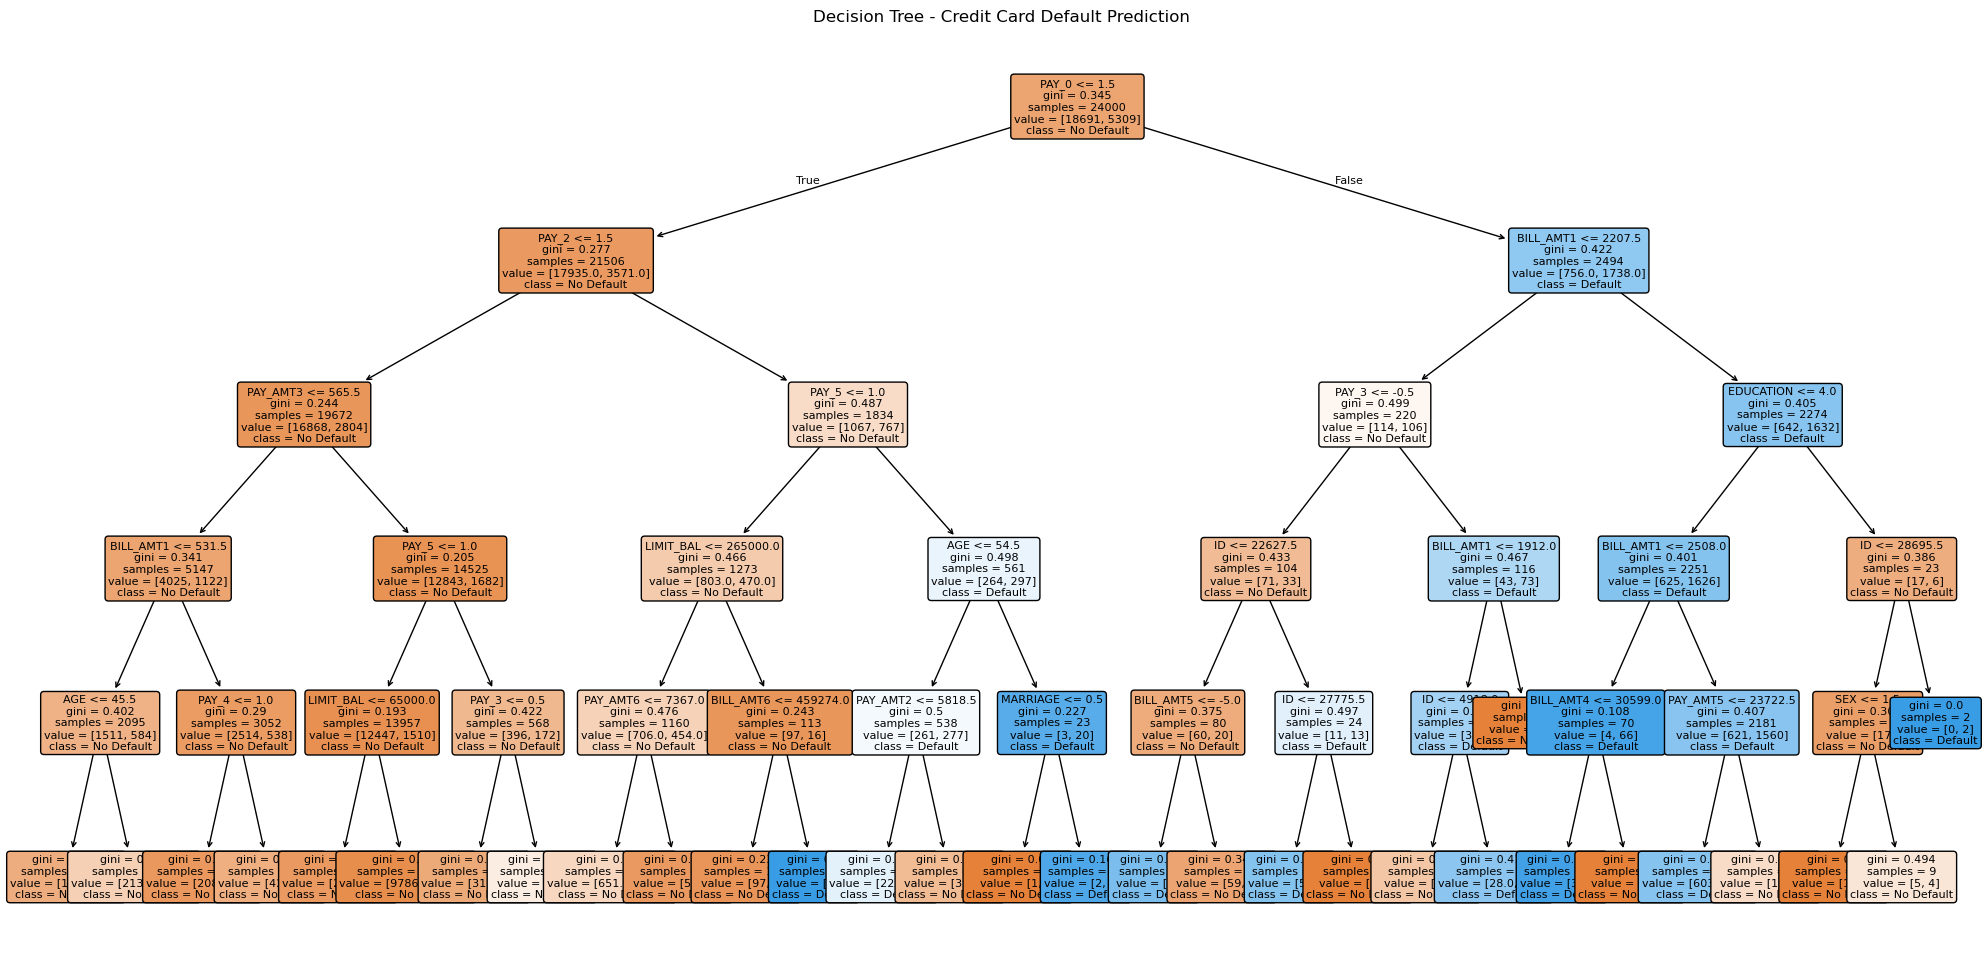

Decision Tree Figure Saved Successfully


In [23]:

# Credit Card Default Prediction
# Task 9 : Decision Tree Classification

# Import Libraries

# Separate Features and Target

X = df.drop("Default", axis=1)
y = df["Default"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Build Decision Tree Model

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=5
)


# Train Model

dt_model.fit(X_train, y_train)


# Prediction

y_pred = dt_model.predict(X_test)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print("DECISION TREE ACCURACY")
print("="*60)
print("Accuracy :", round(accuracy*100,2),"%")


# Confusion Matrix

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Feature Importance

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":dt_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance")
print(importance)
print("\nDecision Tree Completed Successfully")



# Decision Tree Visualization

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(25,12))

# Plot Decision Tree
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True,
    rounded=True,
    fontsize=8
)

# Title
plt.title("Decision Tree - Credit Card Default Prediction")

# Show Figure
plt.show()
print("Decision Tree Figure Saved Successfully")
